In [40]:
import pandas as pd

In [41]:
#joint prob table
data = {
"X":["MedA","MedA","MedA","MedA","Other","Other","Other","Other"],
"Y":["Yes","Yes","No","No","Yes","Yes","No","No"],
"Z":["MedA","Other","MedA","Other","MedA","Other","MedA","Other"],
"P":[0.116,0.274,0.010,0.101,0.334,0.079,0.051,0.036]
}

df = pd.DataFrame(data)

df

,X,Y,Z,P
0,MedA,Yes,MedA,0.116
1,MedA,Yes,Other,0.274
2,MedA,No,MedA,0.010
3,MedA,No,Other,0.101
4,Other,Yes,MedA,0.334
5,Other,Yes,Other,0.079
6,Other,No,MedA,0.051
7,Other,No,Other,0.036


In [42]:
#prob of AI recommendation
P_Z = df.groupby("Z")["P"].sum()

print("Probability of AI recommendation")
print(P_Z)

Probability of AI recommendation
Z
MedA     0.511
Other    0.490
Name: P, dtype: float64


In [43]:
#propensity scores
propensity = df[df["X"]=="MedA"].groupby("Z")["P"].sum() / P_Z

print("Propensity Scores P(X=MedA | Z)")
print(propensity)

Propensity Scores P(X=MedA | Z)
Z
MedA     0.246575
Other    0.765306
Name: P, dtype: float64


In [44]:
#inverse propensity weights
inverse_weights = 1 / propensity

print("Inverse Propensity Weights")
print(inverse_weights)

Inverse Propensity Weights
Z
MedA     4.055556
Other    1.306667
Name: P, dtype: float64


In [45]:
#remission probability given AI advice
remission = df[df["Y"]=="Yes"].groupby("Z")["P"].sum() / P_Z

print("P(Remission | AI Advice)")
print(remission)

P(Remission | AI Advice)
Z
MedA     0.880626
Other    0.720408
Name: P, dtype: float64


In [47]:
#expected remission under AI system
expected_remission = (remission * P_Z).sum()

print("Expected remission under AI system =", expected_remission)

Expected remission under AI system = 0.803


In [48]:
#clinician prescription given AI recommendation
clinician_behavior = df.groupby(["Z","X"])["P"].sum().unstack() / P_Z

print("Clinician Prescription given AI Recommendation")
print(clinician_behavior)

Clinician Prescription given AI Recommendation
X          MedA     Other
Z                        
MedA   0.246575  0.785714
Other  0.733855  0.234694


## Causal DAG for AI Advice, Clinician Prescription, and Remission

The causal relationships in Question 04 can be represented using a Directed Acyclic Graph (DAG).

Z : Artificial Intelligence recommendation  
X : Clinician prescription  
Y : Patient remission  

AI advice influences clinician prescriptions, which in turn affect patient outcomes.

Z → X → Y

AI advice may also directly affect remission because clinicians may partially follow or ignore the AI recommendation.

Z → Y

This structure creates potential **treatment selection bias**, which we correct using **propensity scores and inverse propensity weighting**.

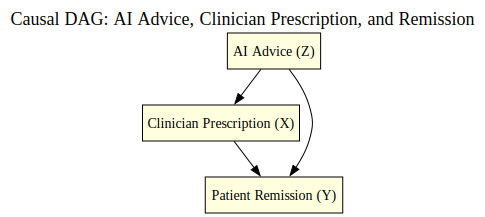

In [49]:
from graphviz import Digraph

g = Digraph()

g.graph_attr.update(
    label='Causal DAG: AI Advice, Clinician Prescription, and Remission',
    labelloc='t',
    fontsize='18'
)

g.attr('node', shape='box', style='filled', fillcolor='lightyellow')

# Nodes
g.node('Z','AI Advice (Z)')
g.node('X','Clinician Prescription (X)')
g.node('Y','Patient Remission (Y)')

# Edges
g.edge('Z','X')
g.edge('X','Y')
g.edge('Z','Y')

g